In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn import preprocessing
from xgboost import XGBClassifier 
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, precision_score, recall_score, f1_score

In [2]:
data = pd.read_csv('../../../data/labeled_dataset.csv')


In [3]:
data['Date'] = pd.to_datetime(data['Date'])

In [4]:
data['regime_binary']= np.where(data['regime']=='bull',1,0)


In [5]:
data['Risk_Adj_Return_20d'] = data['Return_20d'] / (data['VIX'] + 0.00001)

data['SPY_Volume_20d_MA'] = data['SPY Volume'].rolling(window=20).mean()

data['Relative_Volume'] = data['SPY Volume'] / data['SPY_Volume_20d_MA']

data['MACD_Hist_Accel'] = data['MACD_Hist'] - data['MACD_Hist'].shift(1)

data = data.drop(columns=['SPY_Volume_20d_MA']).dropna()

In [6]:

data['lagged_target_5'] = data['regime_binary'].shift(-5)

In [7]:
data_1 = data.dropna(subset=['lagged_target_5'])
# data_1 = data.dropna(subset=['lagged_target_1'])



In [8]:
stationary_features = [
    'Return', 'Return_5d', 'Return_20d', 'Return_Smooth', 
    'RSI_14', 'MACD_Hist', 'Drawdown', 
    'VIX', 'VIX_Change', 'VIX_Change_5d', 
    'GDP_YoY', 'Core_Inflation_YoY', 'M2_YoY', 'Unemployment',
    'Risk_Adj_Return_20d','Relative_Volume',
    'MACD_Hist_Accel'
]

In [9]:

X = data_1[stationary_features]
y = data_1['lagged_target_5']



In [10]:
total_rows = len(data_1)

train_end = int(total_rows * 0.70)
val_end = int(total_rows * 0.85) 


scaler = preprocessing.StandardScaler()

X_train = X.iloc[:train_end]
X_train = scaler.fit_transform(X_train)
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
X_val = scaler.transform(X_val)
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
X_test = scaler.transform(X_test)
y_test = y.iloc[val_end:]

In [11]:

logit_model = sm.Logit(y_train, sm.add_constant(X_train))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.432764
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:        lagged_target_5   No. Observations:                 5629
Model:                          Logit   Df Residuals:                     5611
Method:                           MLE   Df Model:                           17
Date:                Mon, 23 Mar 2026   Pseudo R-squ.:                  0.3626
Time:                        19:24:20   Log-Likelihood:                -2436.0
converged:                       True   LL-Null:                       -3821.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4468      0.039     11.503      0.000       0.371       0.523
x1            -0.0797      0.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'const'),
  Text(1, 0, 'Return'),
  Text(2, 0, 'Return_5d'),
  Text(3, 0, 'Return_20d'),
  Text(4, 0, 'Return_Smooth'),
  Text(5, 0, 'RSI_14'),
  Text(6, 0, 'MACD_Hist'),
  Text(7, 0, 'Drawdown'),
  Text(8, 0, 'VIX'),
  Text(9, 0, 'VIX_Change'),
  Text(10, 0, 'VIX_Change_5d'),
  Text(11, 0, 'GDP_YoY'),
  Text(12, 0, 'Core_Inflation_YoY'),
  Text(13, 0, 'M2_YoY'),
  Text(14, 0, 'Unemployment'),
  Text(15, 0, 'Risk_Adj_Return_20d'),
  Text(16, 0, 'Relative_Volume'),
  Text(17, 0, 'MACD_Hist_Accel')])

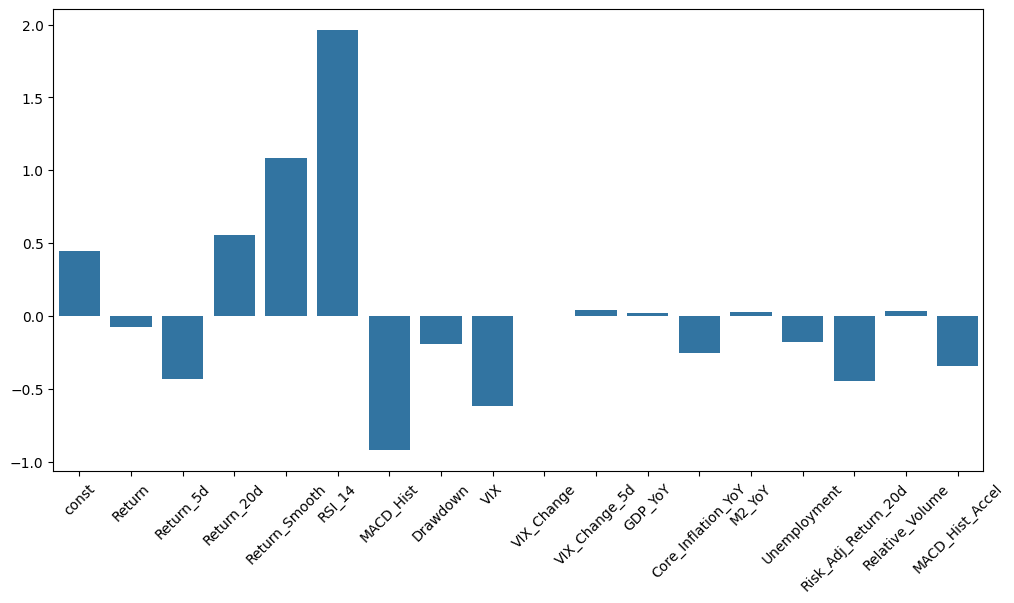

In [12]:
plt.figure(figsize=(12, 6))
names = ['const'] + list(X.columns)
sns.barplot(x=names, y=result.params.values)
plt.xticks(rotation=45)

In [13]:
threshold = 0.5
y_pred_prob_val = result.predict(sm.add_constant(X_val))
y_pred_val = (y_pred_prob_val >= threshold).astype(int)


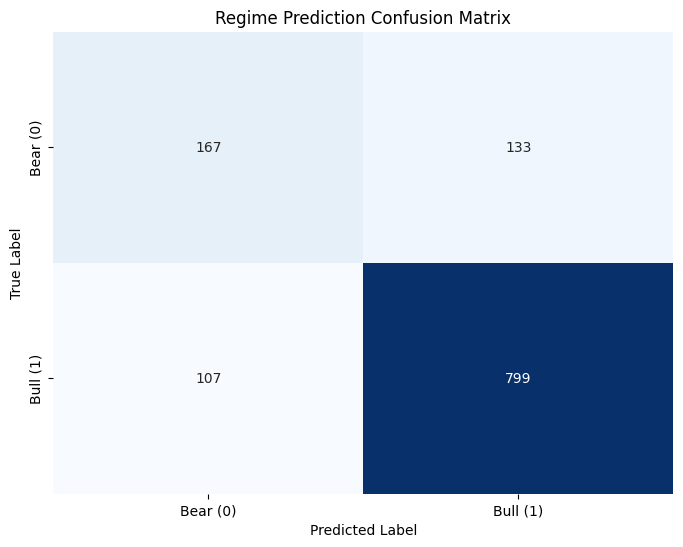

In [14]:

cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bear (0)', 'Bull (1)'], 
            yticklabels=['Bear (0)', 'Bull (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Regime Prediction Confusion Matrix')
plt.show()

In [15]:

print(classification_report(y_val, y_pred_val, target_names=['Bear (0)', 'Bull (1)']))

              precision    recall  f1-score   support

    Bear (0)       0.61      0.56      0.58       300
    Bull (1)       0.86      0.88      0.87       906

    accuracy                           0.80      1206
   macro avg       0.73      0.72      0.73      1206
weighted avg       0.80      0.80      0.80      1206



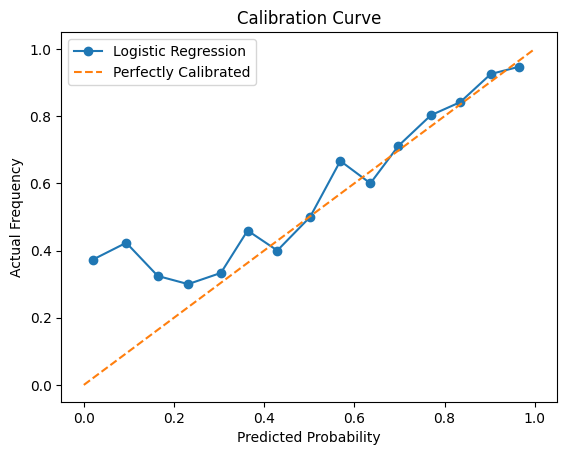

In [16]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_val, y_pred_prob_val, n_bins=15)

plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Frequency')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import fbeta_score
thresholds = np.linspace(0, 1, 50)
beta = 2 
f_scores = []
for t in thresholds:

    y_pred_temp = (y_pred_prob_val >= t).astype(int)
    f_scores.append(fbeta_score(y_val, y_pred_temp, beta=beta, pos_label=0))

best_threshold_f = thresholds[np.argmax(f_scores)]
print(f"Best Threshold (F-{beta} Score): {best_threshold_f:.4f}")

Best Threshold (F-2 Score): 0.8367


Text(0, 0.5, 'F_beta_score')

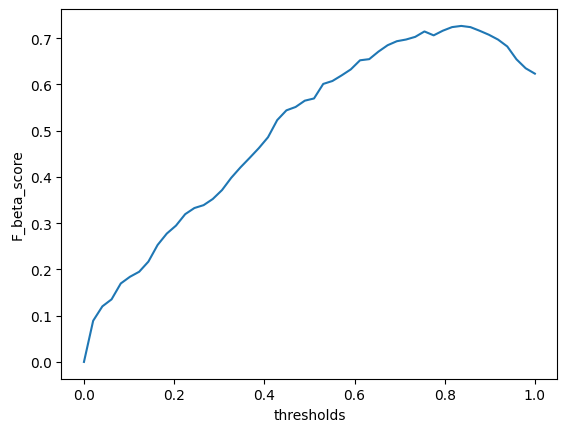

In [18]:
sns.lineplot(x=thresholds, y=f_scores)
plt.xlabel('thresholds')
plt.ylabel('F_beta_score')

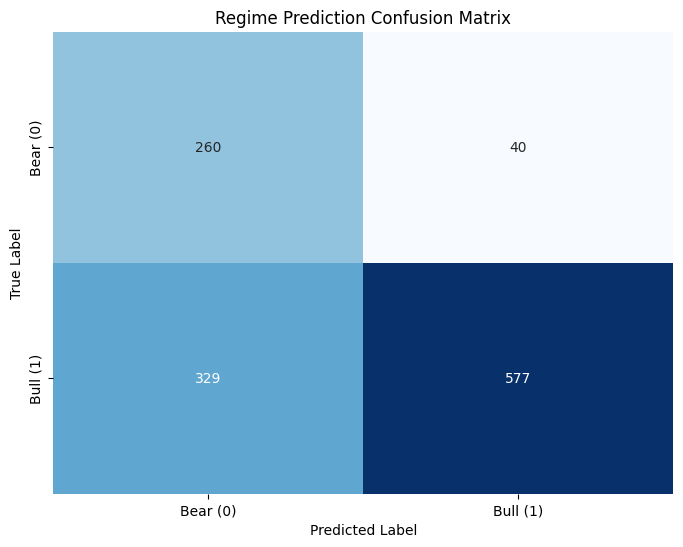

              precision    recall  f1-score   support

    Bear (0)       0.44      0.87      0.58       300
    Bull (1)       0.94      0.64      0.76       906

    accuracy                           0.69      1206
   macro avg       0.69      0.75      0.67      1206
weighted avg       0.81      0.69      0.71      1206



In [19]:
threshold = 0.8367
y_pred_prob_val = result.predict(sm.add_constant(X_val))
y_pred_val = (y_pred_prob_val >= threshold).astype(int)
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bear (0)', 'Bull (1)'], 
            yticklabels=['Bear (0)', 'Bull (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Regime Prediction Confusion Matrix')
plt.show()
print(classification_report(y_val, y_pred_val, target_names=['Bear (0)', 'Bull (1)']))

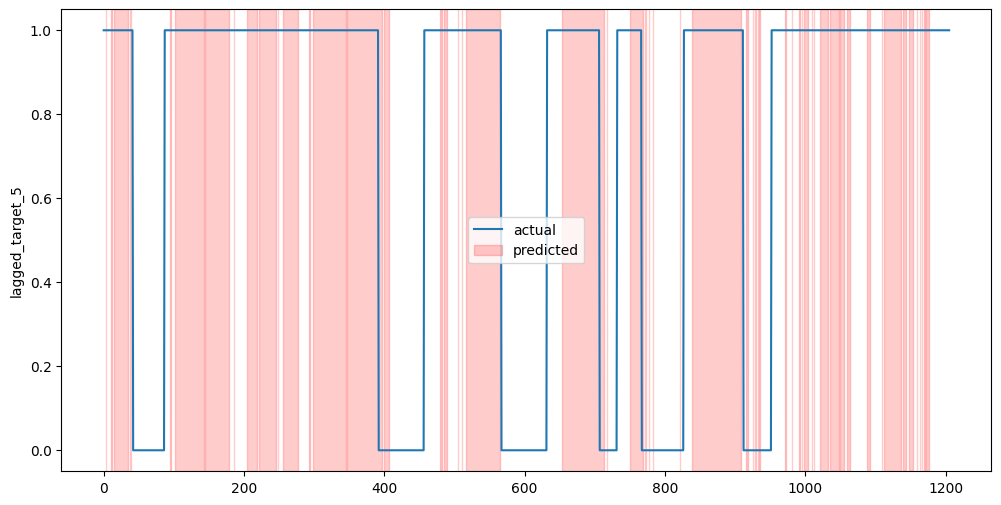

In [20]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val, label='actual')
plt.fill_between(
    range(len(X_val)),
    0, 1, 
    where=(y_pred_val == 1),              
    color='red',                              
    alpha=0.2,                                 
    transform=plt.gca().get_xaxis_transform(), 
    label='predicted'
)

plt.legend()

In [21]:
model =  XGBClassifier(n_estimators=150, random_state=0,max_depth=5, learning_rate=0.1)

model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10  
)

[0]	validation_0-logloss:0.62838	validation_1-logloss:0.59336
[10]	validation_0-logloss:0.38669	validation_1-logloss:0.44680
[20]	validation_0-logloss:0.28552	validation_1-logloss:0.40152
[30]	validation_0-logloss:0.21941	validation_1-logloss:0.36501
[40]	validation_0-logloss:0.18064	validation_1-logloss:0.34106
[50]	validation_0-logloss:0.14371	validation_1-logloss:0.33287
[60]	validation_0-logloss:0.12144	validation_1-logloss:0.32598
[70]	validation_0-logloss:0.10236	validation_1-logloss:0.32943
[80]	validation_0-logloss:0.08791	validation_1-logloss:0.33014
[90]	validation_0-logloss:0.07519	validation_1-logloss:0.32918
[100]	validation_0-logloss:0.06599	validation_1-logloss:0.33106
[110]	validation_0-logloss:0.05825	validation_1-logloss:0.32798
[120]	validation_0-logloss:0.05162	validation_1-logloss:0.33012
[130]	validation_0-logloss:0.04574	validation_1-logloss:0.32873
[140]	validation_0-logloss:0.04047	validation_1-logloss:0.32495
[149]	validation_0-logloss:0.03665	validation_1-log

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [22]:
results = model.evals_result()

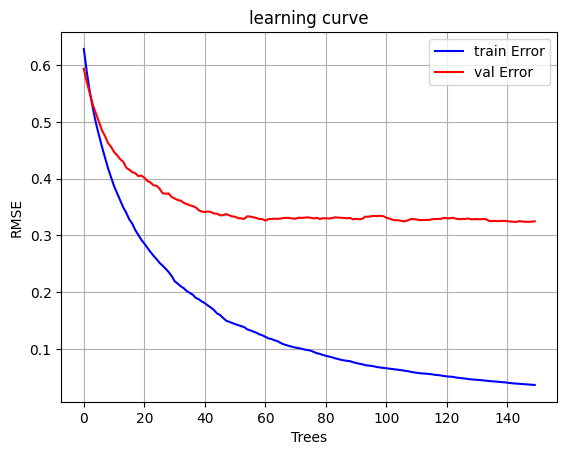

In [23]:
results = model.evals_result()
train_rmse = results['validation_0']['logloss']
val_rmse = results['validation_1']['logloss']

plt.plot(train_rmse, label='train Error', color='blue')
plt.plot(val_rmse, label='val Error', color='red')
plt.title('learning curve')
plt.xlabel('Trees')
plt.ylabel('RMSE')
plt.legend()
plt.grid()
plt.show()

<Axes: >

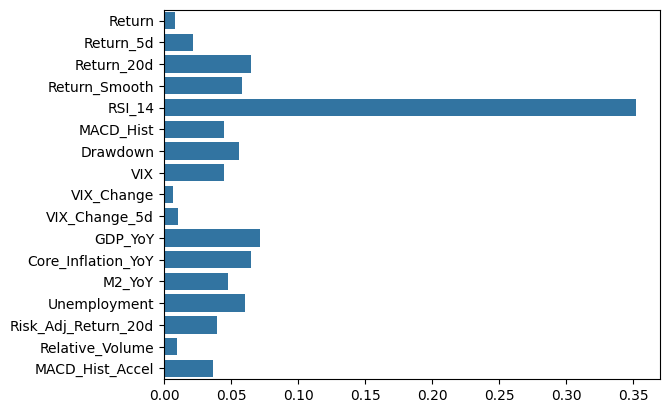

In [24]:
sns.barplot(x=model.feature_importances_, y=names[1:])

Best Threshold (Youden's J): 0.8560


<Axes: >

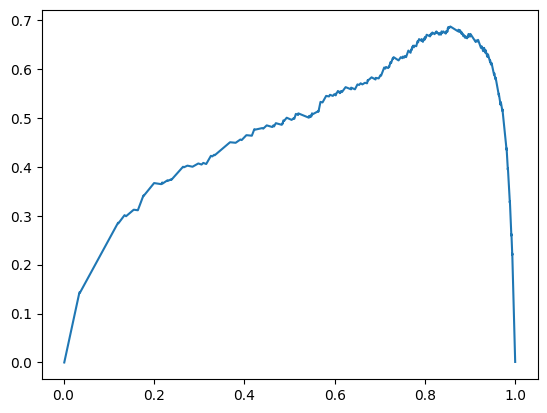

In [25]:
y_pred_prob_val = model.predict_proba(X_val)[:, 1].flatten()


fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob_val)
# J = TPR – FPR
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]
print(f"Best Threshold (Youden's J): {best_threshold:.4f}")
sns.lineplot(x=thresholds, y=j_scores)

In [26]:
# y_pred_val = model.predict(X_val)
best_threshold = 0.838
y_pred_val = (y_pred_prob_val >= best_threshold).astype(int)

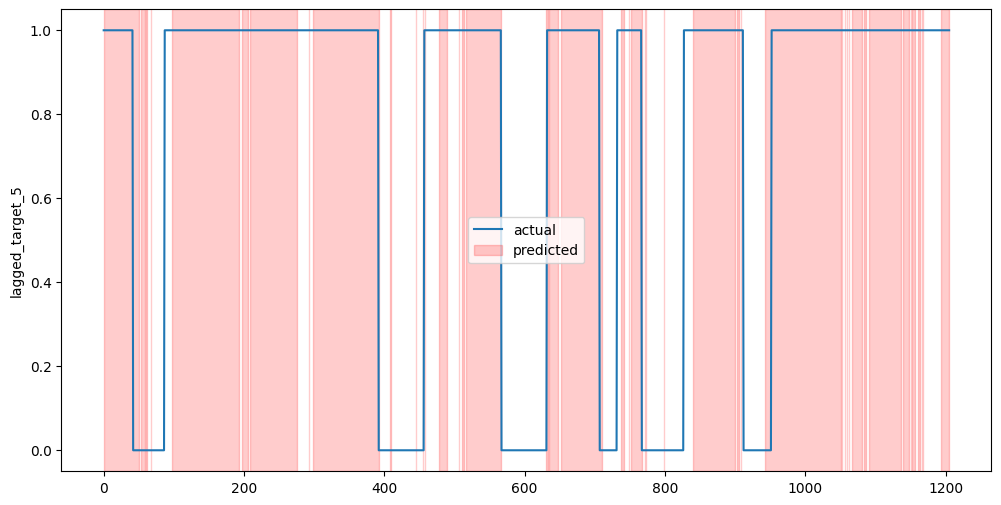

In [27]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val, label='actual')
plt.fill_between(
    range(len(X_val)),
    0, 1, 
    where=(y_pred_val == 1),              
    color='red',                              
    alpha=0.2,                                 
    transform=plt.gca().get_xaxis_transform(), 
    label='predicted'
)

plt.legend()

<Axes: xlabel='col_0', ylabel='lagged_target_5'>

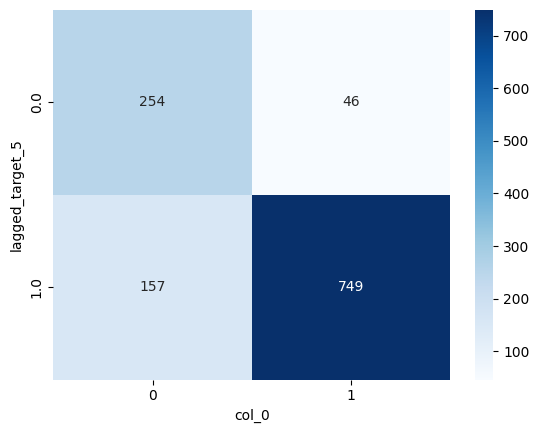

In [28]:
sns.heatmap(pd.crosstab(y_val, y_pred_val), annot=True, fmt='d', cmap='Blues')

<Axes: xlabel='col_0', ylabel='lagged_target_5'>

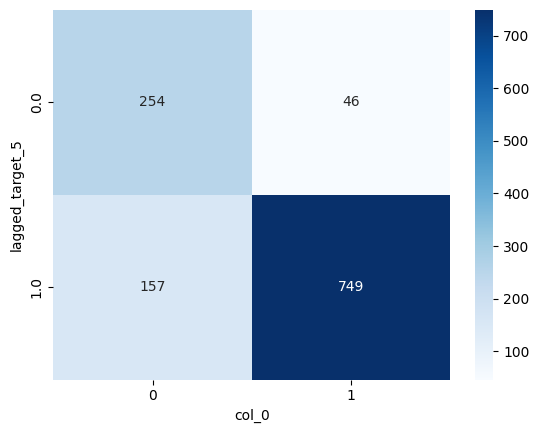

In [29]:
sns.heatmap(pd.crosstab(y_val, y_pred_val), annot=True, fmt='d', cmap='Blues')

In [30]:
import shap
explainer = shap.TreeExplainer(model)

shap_values = explainer(pd.DataFrame(X_val, columns=names[1:]))

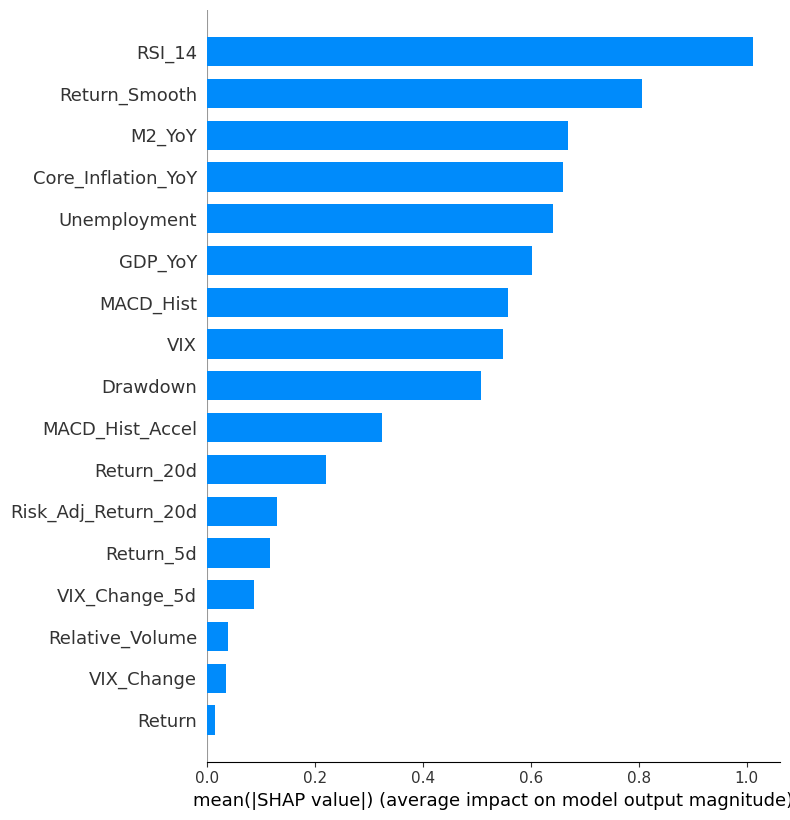

In [31]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, feature_names=names[1:], plot_type='bar')

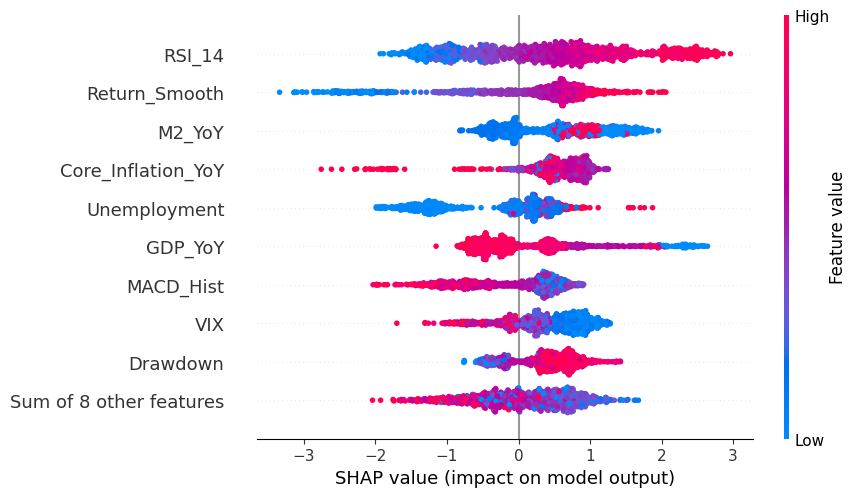

In [32]:
shap.plots.beeswarm(shap_values)


In [33]:
from pathlib import Path

LOGISTIC_OUTPUT_DIR = Path("../../../reports/trained_logistic/basecase_5days")
XGBOOST_OUTPUT_DIR = Path("../../../reports/trained_xgboost/basecase_5days")

LOGISTIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
XGBOOST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

validation_dates = data_1["Date"].iloc[train_end:val_end].reset_index(drop=True)
test_dates = data_1["Date"].iloc[val_end:].reset_index(drop=True)

logistic_pred_prob_val = result.predict(sm.add_constant(X_val))
logistic_pred_val = (logistic_pred_prob_val >= threshold).astype(int)
logistic_pred_prob_test = result.predict(sm.add_constant(X_test))
logistic_pred_test = (logistic_pred_prob_test >= threshold).astype(int)

logistic_confusion = pd.DataFrame(
    confusion_matrix(y_val, logistic_pred_val),
    index=["actual_bear", "actual_bull"],
    columns=["pred_bear", "pred_bull"],
)
logistic_confusion.to_csv(LOGISTIC_OUTPUT_DIR / "confusion_matrix.csv")

logistic_metrics = pd.DataFrame([
    {
        "model": "logistic_regression",
        "split": "validation",
        "horizon": "5days",
        "accuracy": accuracy_score(y_val, logistic_pred_val),
        "precision": precision_score(y_val, logistic_pred_val, zero_division=0),
        "recall": recall_score(y_val, logistic_pred_val, zero_division=0),
        "f1_score": f1_score(y_val, logistic_pred_val, zero_division=0),
        "threshold": threshold,
    }
])
logistic_metrics.to_csv(LOGISTIC_OUTPUT_DIR / "validation_metrics.csv", index=False)

logistic_test_metrics = pd.DataFrame([
    {
        "model": "logistic_regression",
        "split": "test",
        "horizon": "5days",
        "accuracy": accuracy_score(y_test, logistic_pred_test),
        "precision": precision_score(y_test, logistic_pred_test, zero_division=0),
        "recall": recall_score(y_test, logistic_pred_test, zero_division=0),
        "f1_score": f1_score(y_test, logistic_pred_test, zero_division=0),
        "threshold": threshold,
    }
])
logistic_test_metrics.to_csv(LOGISTIC_OUTPUT_DIR / "test_metrics.csv", index=False)

pd.DataFrame({"feature": names, "coefficient": result.params.values}).to_csv(LOGISTIC_OUTPUT_DIR / "coefficients.csv", index=False)

pd.DataFrame({
    "Date": validation_dates,
    "y_true": y_val.reset_index(drop=True),
    "y_pred": pd.Series(logistic_pred_val).reset_index(drop=True),
    "y_pred_prob": pd.Series(logistic_pred_prob_val).reset_index(drop=True),
    "model": "logistic_regression",
    "split": "validation",
    "horizon": "5days",
}).to_csv(LOGISTIC_OUTPUT_DIR / "predictions.csv", index=False)

pd.DataFrame({
    "Date": test_dates,
    "y_true": y_test.reset_index(drop=True),
    "y_pred": pd.Series(logistic_pred_test).reset_index(drop=True),
    "y_pred_prob": pd.Series(logistic_pred_prob_test).reset_index(drop=True),
    "model": "logistic_regression",
    "split": "test",
    "horizon": "5days",
}).to_csv(LOGISTIC_OUTPUT_DIR / "test_predictions.csv", index=False)

plt.figure(figsize=(6, 5))
sns.heatmap(logistic_confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix (5 Days)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(LOGISTIC_OUTPUT_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.close()

plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val.reset_index(drop=True), label='actual')
plt.fill_between(
    range(len(X_val)),
    0,
    1,
    where=(pd.Series(logistic_pred_val).reset_index(drop=True) == 1),
    color='red',
    alpha=0.2,
    transform=plt.gca().get_xaxis_transform(),
    label='predicted',
)
plt.title('Logistic Regression Prediction Timeline (5 Days)')
plt.xlabel('Validation Observation')
plt.ylabel('Regime')
plt.legend()
plt.tight_layout()
plt.savefig(LOGISTIC_OUTPUT_DIR / "prediction_timeline.png", dpi=180, bbox_inches="tight")
plt.close()

xgb_pred_prob_test = model.predict_proba(X_test)[:, 1]
y_pred_test = (xgb_pred_prob_test >= best_threshold).astype(int)

xgb_confusion = pd.DataFrame(
    confusion_matrix(y_val, y_pred_val),
    index=["actual_bear", "actual_bull"],
    columns=["pred_bear", "pred_bull"],
)
xgb_confusion.to_csv(XGBOOST_OUTPUT_DIR / "confusion_matrix.csv")

xgb_metrics = pd.DataFrame([
    {
        "model": "xgboost",
        "split": "validation",
        "horizon": "5days",
        "accuracy": accuracy_score(y_val, y_pred_val),
        "precision": precision_score(y_val, y_pred_val, zero_division=0),
        "recall": recall_score(y_val, y_pred_val, zero_division=0),
        "f1_score": f1_score(y_val, y_pred_val, zero_division=0),
        "threshold": best_threshold,
    }
])
xgb_metrics.to_csv(XGBOOST_OUTPUT_DIR / "validation_metrics.csv", index=False)

xgb_test_metrics = pd.DataFrame([
    {
        "model": "xgboost",
        "split": "test",
        "horizon": "5days",
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test, zero_division=0),
        "recall": recall_score(y_test, y_pred_test, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_test, zero_division=0),
        "threshold": best_threshold,
    }
])
xgb_test_metrics.to_csv(XGBOOST_OUTPUT_DIR / "test_metrics.csv", index=False)

pd.DataFrame({
    "Date": validation_dates,
    "y_true": y_val.reset_index(drop=True),
    "y_pred": pd.Series(y_pred_val).reset_index(drop=True),
    "y_pred_prob": pd.Series(y_pred_prob_val).reset_index(drop=True),
    "model": "xgboost",
    "split": "validation",
    "horizon": "5days",
}).to_csv(XGBOOST_OUTPUT_DIR / "predictions.csv", index=False)

pd.DataFrame({
    "Date": test_dates,
    "y_true": y_test.reset_index(drop=True),
    "y_pred": pd.Series(y_pred_test).reset_index(drop=True),
    "y_pred_prob": pd.Series(xgb_pred_prob_test).reset_index(drop=True),
    "model": "xgboost",
    "split": "test",
    "horizon": "5days",
}).to_csv(XGBOOST_OUTPUT_DIR / "test_predictions.csv", index=False)
